# Exercise 5

In [ ]:
import numpy as np
import pandas as pd

import scipy.stats as stats


## Part 1: ANOVA

A teacher wants to investigate whether different teaching methods affect students’ exam scores. The dataset contains 50 students, each assigned to one of three teaching methods (A, B, or C).

Question: "Is there a difference in mean exam scores among students taught using three different teaching methods?"

- Independent variable (factor): Teaching Method (A, B, C)
- Dependent variable: Exam Score (numeric)

In [ ]:
exam_scores_url = (
    "https://github.com/robitussin/CCDATSCL_EXERCISES/"
    "blob/f56f00991116fcb717a8827d324aa6f599dea366/exam_scores.csv?raw=true"
)

df_exam_scores = pd.read_csv(exam_scores_url).copy()
df_exam_scores


,StudentID,Method,Score
0,1,A,79
1,2,A,77
2,3,A,82
3,4,A,75
4,5,A,80
5,6,A,78
6,7,A,83
7,8,A,76
8,9,A,81
9,10,A,74


Calculate the number of students in each teaching method.

In [ ]:
method_counts = (
    df_exam_scores
    .groupby("Method")
    .size()
    .to_frame(name="count")
)
method_counts


,count
Method,
A,17
B,17
C,16


Compute the mean and standard deviation of exam scores for each group.

In [ ]:
# Compute mean and standard deviation for each teaching method group
summary_stats = (
    df_exam_scores
    .pivot_table(index="Method", values="Score", aggfunc=["mean", "std"])
)

summary_stats.columns = ["mean", "std"]

print("Mean and Standard Deviation by Teaching Method:")
print(summary_stats)

Mean and Standard Deviation by Teaching Method:
             mean       std
Method                     
A       78.588235  2.575336
B       86.294118  2.365500
C       71.937500  1.768945


Use a plot to show the exam scores by teaching method.

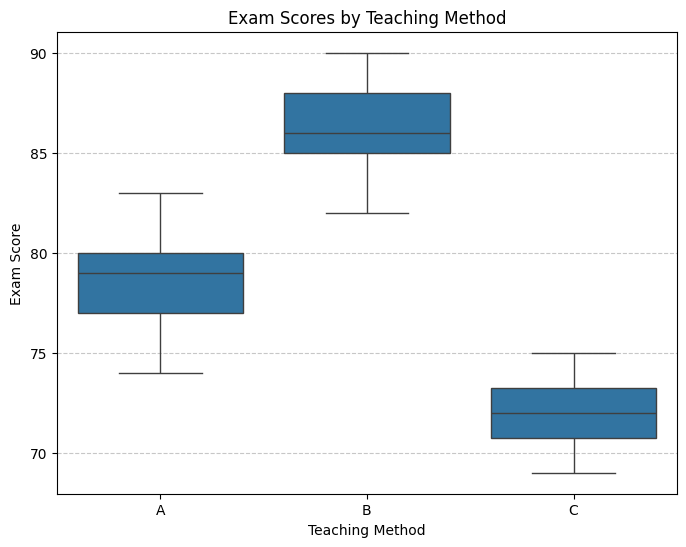

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df_exam_scores, x="Method", y="Score", ax=ax)
ax.set_title("Exam Scores by Teaching Method")
ax.set_xlabel("Teaching Method")
ax.set_ylabel("Exam Score")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Perform the ANOVA Test
- Use scipy.stats.f_oneway to conduct a one-way ANOVA.
- Report the F-statistic and p-value.
- Using a significance level of α = 0.05, state whether you reject or fail to reject H₀.

In [6]:
# Collect the exam scores for each teaching method
groups = [
    group["Score"].values
    for _, group in df_exam_scores.groupby("Method")
]

# Perform one-way ANOVA
f_statistic, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")


F-statistic: 165.18
P-value: 0.000


Interpret the results. What does it say about the relationship between teaching method and exam scores?

In [7]:
# State whether to reject or fail to reject H₀
alpha = 0.05

reject_msg = (
    "Since the p-value ({p:.3f}) is less than alpha ({a}), we reject the null hypothesis (H₀).\n"
    "This suggests there is a significant difference in mean exam scores among the teaching methods."
)
fail_msg = (
    "Since the p-value ({p:.3f}) is greater than or equal to alpha ({a}), we fail to reject the null hypothesis (H₀).\n"
    "This suggests there is no significant difference in mean exam scores among the teaching methods."
)

message = reject_msg if p_value < alpha else fail_msg
print(message.format(p=p_value, a=alpha))


Since the p-value (0.000) is less than alpha (0.05), we reject the null hypothesis (H₀).
This suggests there is a significant difference in mean exam scores among the teaching methods.


## Part 2: Chi-squared

A survey was conducted to see if there is a relationship between gender and littering behavior.

Question:
"Is gender associated with littering behavior?"

Each row represents one person.

In [8]:
littering_url = (
    "https://github.com/robitussin/CCDATSCL_EXERCISES/"
    "blob/f56f00991116fcb717a8827d324aa6f599dea366/litteringdata.csv?raw=true"
)

df_littering_data = pd.read_csv(littering_url).copy()
df_littering_data

,ID,Gender,Litter
0,1,Male,Yes
1,2,Male,Yes
2,3,Male,Yes
3,4,Male,Yes
4,5,Male,Yes
5,6,Male,Yes
6,7,Male,Yes
7,8,Male,Yes
8,9,Male,Yes
9,10,Male,Yes


Count the number of observations in each category for Gender and Litter separately.

In [9]:
gender_counts = df_littering_data["Gender"].value_counts()
litter_counts = df_littering_data["Litter"].value_counts()

print("Gender counts:")
print(gender_counts)
print("\nLitter counts:")
print(litter_counts)

Gender counts:
Gender
Male      20
Female    20
Name: count, dtype: int64

Litter counts:
Litter
No     22
Yes    18
Name: count, dtype: int64


Using `pd.crosstab()`, create a contingency table showing counts of littering behavior for each gender.
- Write down the row totals, column totals, and grand total from the table.

In [10]:
contingency_table = pd.crosstab(
    index=df_littering_data["Gender"],
    columns=df_littering_data["Litter"],
)
display(contingency_table)

row_totals = contingency_table.sum(axis="columns")
col_totals = contingency_table.sum(axis="index")
grand_total = col_totals.sum()

print("\nRow Totals:")
print(row_totals)

print("\nColumn Totals:")
print(col_totals)

print(f"\nGrand Total: {grand_total}")

Litter,No,Yes
Gender,,
Female,14,6
Male,8,12



Row Totals:
Gender
Female    20
Male      20
dtype: int64

Column Totals:
Litter
No     22
Yes    18
dtype: int64

Grand Total: 40


State the null hypothesis (H₀) and alternative hypothesis (H₁) for this chi-squared test.

In [11]:
hypotheses = [
    "Null Hypothesis (H₀): Gender and littering behavior are independent.",
    "Alternative Hypothesis (H₁): Gender and littering behavior are associated (not independent).",
]

for statement in hypotheses:
    print(statement)

Null Hypothesis (H₀): Gender and littering behavior are independent.
Alternative Hypothesis (H₁): Gender and littering behavior are associated (not independent).


Use scipy.stats.chi2_contingency to calculate:
- Chi-squared statistic
- p-value
- Degrees of freedom

Using a significance level of `α = 0.05`, determine whether to reject or fail to reject H₀.


In [12]:
chi2_statistic, p_value_chi2, dof, expected_freq = stats.chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value_chi2:.3f}")
print(f"Degrees of freedom: {dof}")

Chi-squared statistic: 2.53
P-value: 0.112
Degrees of freedom: 1


Interpret your results. Is there evidence that gender and littering behavior are associated?

In [13]:
alpha = 0.05

decision_lines = []
if p_value_chi2 < alpha:
    decision_lines.append(
        f"Since the p-value ({p_value_chi2:.3f}) is less than alpha ({alpha}), we reject the null hypothesis (H₀)."
    )
    decision_lines.append("There is evidence that gender and littering behavior are associated.")
else:
    decision_lines.append(
        f"Since the p-value ({p_value_chi2:.3f}) is greater than or equal to alpha ({alpha}), we fail to reject the null hypothesis (H₀)."
    )
    decision_lines.append("There is no sufficient evidence to suggest an association between gender and littering behavior.")

for line in decision_lines:
    print(line)

print("\nInterpretation:")
print(f"With a chi-squared statistic of {chi2_statistic:.2f} and a p-value of {p_value_chi2:.3f},")
print(f"we fail to reject the null hypothesis at α = {alpha}. This means there is insufficient")
print("statistical evidence to conclude that gender and littering behavior are associated.")
print("The observed differences in littering behavior between genders could be due to random")
print("chance rather than a true relationship between the two variables.")

Since the p-value (0.112) is greater than or equal to alpha (0.05), we fail to reject the null hypothesis (H₀).
There is no sufficient evidence to suggest an association between gender and littering behavior.

Interpretation:
With a chi-squared statistic of 2.53 and a p-value of 0.112,
we fail to reject the null hypothesis at α = 0.05. This means there is insufficient
statistical evidence to conclude that gender and littering behavior are associated.
The observed differences in littering behavior between genders could be due to random
chance rather than a true relationship between the two variables.
